# H3 Analysis Plan — Governance as a Moderator Between AI Readiness and Sustainability
**Plan file:** `07_H3_plan.md`
**Plan code:** `h3`
**Dataset:** `data/3_processed_data/master_features/panel_dataset_2020_2023.parquet`
**Date:** 2026-05-26

> This analysis tests H3: whether governance quality (WGI composite) positively moderates the relationship between AI readiness and SDG index scores across 26 countries (2020–2023), using a full panel moderation model with a mean-centred interaction term.

In [1]:
import os
os.chdir("/Users/mohamedinas/Desktop/SE_projects/9_fathima_stat_support/version_v1/8_interview_prep")
print("Working dir:", os.getcwd())

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import scipy.stats as stats
import statsmodels.api as sm
import statsmodels.formula.api as smf

try:
    from linearmodels.panel import PanelOLS, RandomEffects
    from linearmodels.panel.results import compare
    HAS_LINEARMODELS = True
except ImportError:
    HAS_LINEARMODELS = False
    print("⚠️  linearmodels not installed — panel models will use statsmodels workaround")

# ── McKinsey dark-navy style constants ────────────────────────────────────────
BG_DARK        = "#0A1628"
GRID_COLOR     = "#1E3A5F"
TEXT_WHITE     = "#FFFFFF"
TEXT_DARK      = "#0A1628"
C1             = "#4FC3F7"   # sky blue  — Developed / Low WGI line
C2             = "#4DB6AC"   # teal      — Developing / Mean WGI line
C3             = "#1A73E8"   # blue      — Lower Governance / High WGI line
C4             = "#FFD600"   # gold      — accent / highlight
C5             = "#FF7043"   # orange    — 5th series

GROUP_COLORS = {
    "Developed":        C1,
    "Developing":       C2,
    "Lower Governance": C3,
}

MCKINSEY_RC = {
    "figure.facecolor": BG_DARK, "figure.figsize": (14, 7), "figure.dpi": 150,
    "axes.facecolor": BG_DARK, "axes.edgecolor": GRID_COLOR,
    "axes.labelcolor": TEXT_WHITE, "axes.titlecolor": TEXT_WHITE,
    "axes.titlesize": 14, "axes.titleweight": "bold", "axes.titlepad": 16,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.spines.left": False, "axes.spines.bottom": False,
    "axes.grid": True, "axes.grid.axis": "y",
    "grid.color": GRID_COLOR, "grid.linestyle": "--", "grid.linewidth": 0.6,
    "lines.linewidth": 2.5,
    "xtick.color": TEXT_WHITE, "ytick.color": TEXT_WHITE,
    "xtick.labelsize": 9, "ytick.labelsize": 9,
    "xtick.major.size": 0, "ytick.major.size": 0,
    "legend.facecolor": BG_DARK, "legend.framealpha": 0.0,
    "legend.labelcolor": TEXT_WHITE, "legend.fontsize": 9,
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica Neue", "DejaVu Sans"],
    "text.color": TEXT_WHITE,
    "savefig.facecolor": BG_DARK, "savefig.bbox": "tight", "savefig.dpi": 150,
}
plt.rcParams.update(MCKINSEY_RC)

import os
os.makedirs("outputs", exist_ok=True)
print("✅ Setup complete — McKinsey theme loaded")

Working dir: /Users/mohamedinas/Desktop/SE_projects/9_fathima_stat_support/version_v1/8_interview_prep


✅ Setup complete — McKinsey theme loaded


## Data Loading
Loading the panel dataset and verifying structure.

In [2]:
DATA_PATH = "data/3_processed_data/master_features/panel_dataset_2020_2023.parquet"
df = pd.read_parquet(DATA_PATH)

print(f"Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Countries: {df['country'].nunique()} | Years: {sorted(df['year'].unique())} | Groups: {df['country_group'].unique().tolist()}")
print("\nColumn dtypes:")
print(df.dtypes.to_string())
df.head(8)

Dataset shape: 104 rows × 7 columns
Countries: 26 | Years: [np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)] | Groups: ['Developed', 'Developing', 'Lower Governance']

Column dtypes:
iso_code                  str
country                   str
country_group             str
year                    int64
ai_readiness_score    float64
sdg_index_score       float32
wgi_composite         float32


,iso_code,country,country_group,year,ai_readiness_score,sdg_index_score,wgi_composite
0,CAN,Canada,Developed,2020,73.158,79.370003,1.504060
1,CAN,Canada,Developed,2021,77.730,79.040001,1.452090
2,CAN,Canada,Developed,2022,77.390,79.209999,1.430138
3,CAN,Canada,Developed,2023,77.070,79.279999,1.419729
4,DNK,Denmark,Developed,2020,75.618,85.010002,1.825962
5,DNK,Denmark,Developed,2021,76.960,84.910004,1.874868
6,DNK,Denmark,Developed,2022,74.790,85.029999,1.863013
7,DNK,Denmark,Developed,2023,73.910,85.250000,1.849802


## Step 1 — Confirm Full Moderation Model Setup

The full moderation model is:

$$\text{SDG}_{it} = \beta_0 + \beta_1 \cdot \text{AI\_centered}_{it} + \beta_2 \cdot \text{WGI\_centered}_{it} + \beta_3 \cdot (\text{AI\_centered}_{it} \times \text{WGI\_centered}_{it}) + \alpha_i + \lambda_t + \varepsilon_{it}$$

Variables are **mean-centred** to reduce multicollinearity. We test Pooled OLS, Fixed Effects (Two-Way), and Random Effects, then use the Hausman test to select the preferred specification.

In [3]:
# ── 1. Create mean-centred variables ─────────────────────────────────────────
ai_mean  = df["ai_readiness_score"].mean()
wgi_mean = df["wgi_composite"].mean()

df["ai_centered"]        = df["ai_readiness_score"] - ai_mean
df["wgi_centered"]       = df["wgi_composite"]       - wgi_mean
df["ai_wgi_interaction"] = df["ai_centered"] * df["wgi_centered"]

print(f"AI Readiness: grand mean = {ai_mean:.4f}, std = {df['ai_readiness_score'].std():.4f}")
print(f"WGI Composite: grand mean = {wgi_mean:.4f}, std = {df['wgi_composite'].std():.4f}")
print(f"Interaction term: mean = {df['ai_wgi_interaction'].mean():.4f}, std = {df['ai_wgi_interaction'].std():.4f}")
print(f"\nCentred variables — correlation check:")
print(df[["ai_centered","wgi_centered","ai_wgi_interaction"]].corr().round(4))

AI Readiness: grand mean = 59.7466, std = 17.2976
WGI Composite: grand mean = 0.3510, std = 1.0247
Interaction term: mean = 15.0597, std = 12.3333

Centred variables — correlation check:
                    ai_centered  wgi_centered  ai_wgi_interaction
ai_centered              1.0000        0.8579             -0.1375
wgi_centered             0.8579        1.0000              0.1427
ai_wgi_interaction      -0.1375        0.1427              1.0000


In [4]:
# ── 2. Pooled OLS (full moderation model) ────────────────────────────────────
X_ols = sm.add_constant(df[["ai_centered","wgi_centered","ai_wgi_interaction"]])
ols_res = sm.OLS(df["sdg_index_score"], X_ols).fit(cov_type="HC3")
print("=== Pooled OLS (Heteroskedasticity-Robust SE) ===")
print(ols_res.summary2().tables[1])
print(f"R² = {ols_res.rsquared:.4f}  |  Adj-R² = {ols_res.rsquared_adj:.4f}  |  N = {int(ols_res.nobs)}")

results_table = [{
    "Model":               "Pooled OLS",
    "β1 (AI_centered)":   round(float(ols_res.params["ai_centered"]), 4),
    "β2 (WGI_centered)":  round(float(ols_res.params["wgi_centered"]), 4),
    "β3 (Interaction)":   round(float(ols_res.params["ai_wgi_interaction"]), 4),
    "SE (β3)":            round(float(ols_res.bse["ai_wgi_interaction"]), 4),
    "p (β3, 2-tail)":     round(float(ols_res.pvalues["ai_wgi_interaction"]), 4),
    "CI lower (β3)":      round(float(ols_res.conf_int().loc["ai_wgi_interaction", 0]), 4),
    "CI upper (β3)":      round(float(ols_res.conf_int().loc["ai_wgi_interaction", 1]), 4),
    "R²":                 round(ols_res.rsquared, 4),
}]

=== Pooled OLS (Heteroskedasticity-Robust SE) ===
                        Coef.  Std.Err.          z         P>|z|     [0.025  \
const               73.975022  0.792676  93.323132  0.000000e+00  72.421406   
ai_centered          0.089373  0.061100   1.462714  1.435455e-01  -0.030382   
wgi_centered         6.959025  0.866802   8.028393  9.875737e-16   5.260125   
ai_wgi_interaction  -0.161819  0.044369  -3.647114  2.652019e-04  -0.248781   

                       0.975]  
const               75.528639  
ai_centered          0.209127  
wgi_centered         8.657925  
ai_wgi_interaction  -0.074857  
R² = 0.8062  |  Adj-R² = 0.8004  |  N = 104


In [5]:
# ── 3. Panel models (FE, RE, Hausman) ────────────────────────────────────────
df_panel = df[["sdg_index_score","ai_centered","wgi_centered","ai_wgi_interaction",
               "country","year"]].dropna().copy()
df_panel = df_panel.set_index(["country","year"])

if HAS_LINEARMODELS:
    # Fixed Effects (Two-Way: entity + time)
    fe_mod = PanelOLS(df_panel["sdg_index_score"],
                      df_panel[["ai_centered","wgi_centered","ai_wgi_interaction"]],
                      entity_effects=True, time_effects=True)
    fe_res = fe_mod.fit(cov_type="clustered", cluster_entity=True)
    print("=== Fixed Effects (Two-Way, Clustered SE) ===")
    print(fe_res.summary.tables[1])
    print(f"R² (within) = {float(fe_res.rsquared):.4f}  |  N = {int(fe_res.nobs)}")

    results_table.append({
        "Model":               "Fixed Effects (Two-Way)",
        "β1 (AI_centered)":   round(float(fe_res.params["ai_centered"]), 4),
        "β2 (WGI_centered)":  round(float(fe_res.params["wgi_centered"]), 4),
        "β3 (Interaction)":   round(float(fe_res.params["ai_wgi_interaction"]), 4),
        "SE (β3)":            round(float(fe_res.std_errors["ai_wgi_interaction"]), 4),
        "p (β3, 2-tail)":     round(float(fe_res.pvalues["ai_wgi_interaction"]), 4),
        "CI lower (β3)":      round(float(fe_res.conf_int().loc["ai_wgi_interaction","lower"]), 4),
        "CI upper (β3)":      round(float(fe_res.conf_int().loc["ai_wgi_interaction","upper"]), 4),
        "R²":                 round(float(fe_res.rsquared), 4),
    })

    # Random Effects
    re_mod = RandomEffects(df_panel["sdg_index_score"],
                           sm.add_constant(df_panel[["ai_centered","wgi_centered","ai_wgi_interaction"]]))
    re_res = re_mod.fit(cov_type="robust")
    print("\n=== Random Effects (Robust SE) ===")
    print(re_res.summary.tables[1])
    print(f"R² = {float(re_res.rsquared):.4f}  |  N = {int(re_res.nobs)}")

    results_table.append({
        "Model":               "Random Effects",
        "β1 (AI_centered)":   round(float(re_res.params["ai_centered"]), 4),
        "β2 (WGI_centered)":  round(float(re_res.params["wgi_centered"]), 4),
        "β3 (Interaction)":   round(float(re_res.params["ai_wgi_interaction"]), 4),
        "SE (β3)":            round(float(re_res.std_errors["ai_wgi_interaction"]), 4),
        "p (β3, 2-tail)":     round(float(re_res.pvalues["ai_wgi_interaction"]), 4),
        "CI lower (β3)":      round(float(re_res.conf_int().loc["ai_wgi_interaction","lower"]), 4),
        "CI upper (β3)":      round(float(re_res.conf_int().loc["ai_wgi_interaction","upper"]), 4),
        "R²":                 round(float(re_res.rsquared), 4),
    })

    # Hausman test
    b_fe = fe_res.params
    b_re = re_res.params.drop("const", errors="ignore")
    common = b_fe.index.intersection(b_re.index)
    diff   = (b_fe[common] - b_re[common]).values
    V_fe   = fe_res.cov.values
    V_re   = re_res.cov.loc[common, common].values
    V_diff = V_fe - V_re
    try:
        from scipy.stats import chi2 as chi2_dist
        chi2_val = float(diff @ np.linalg.inv(V_diff) @ diff)
        df_h     = len(common)
        p_h      = 1 - chi2_dist.cdf(chi2_val, df_h)
        print(f"\n=== Hausman Test ===")
        print(f"Chi² = {chi2_val:.4f}, df = {df_h}, p = {p_h:.4f}")
        if p_h < 0.05:
            hausman_decision = "Fixed Effects preferred (p < 0.05)"
            selected_model, selected_res = "Fixed Effects", fe_res
        elif chi2_val < 0:
            hausman_decision = "Degenerate test (V_diff not PD, likely small-N issue) — defaulting to Random Effects"
            selected_model, selected_res = "Random Effects", re_res
        else:
            hausman_decision = "Random Effects preferred (p ≥ 0.05)"
            selected_model, selected_res = "Random Effects", re_res
        print(f"Decision: {hausman_decision}")
    except np.linalg.LinAlgError:
        print("Hausman: matrix not invertible — defaulting to Fixed Effects")
        selected_model, selected_res = "Fixed Effects", fe_res

else:
    # statsmodels fallback — entity dummies
    dummies = pd.get_dummies(df["country"], drop_first=True, prefix="c")
    X_fe = sm.add_constant(pd.concat([df[["ai_centered","wgi_centered","ai_wgi_interaction"]], dummies], axis=1))
    fe_res = sm.OLS(df["sdg_index_score"], X_fe).fit(cov_type="HC3")
    selected_model, selected_res = "Within OLS (fallback)", fe_res
    print("⚠️  Using statsmodels entity-dummy FE as fallback")

reg_df = pd.DataFrame(results_table)
print("\n=== Summary Table ===")
display(reg_df)
reg_df.to_csv("outputs/h3_moderation_model_results.csv", index=False)
print("\n✅ Saved: outputs/h3_moderation_model_results.csv")
print(f"\n✨ Selected model for hypothesis test: {selected_model}")

=== Fixed Effects (Two-Way, Clustered SE) ===
                                 Parameter Estimates                                  
                    Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
--------------------------------------------------------------------------------------
ai_centered            0.0210     0.0162     1.2994     0.1980     -0.0112      0.0533
wgi_centered           0.7186     0.7957     0.9030     0.3695     -0.8677      2.3048
ai_wgi_interaction     0.0045     0.0142     0.3151     0.7536     -0.0238      0.0327
R² (within) = 0.0570  |  N = 104

=== Random Effects (Robust SE) ===
                                 Parameter Estimates                                  
                    Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
--------------------------------------------------------------------------------------
const                  72.056     1.2261     58.770     0.0000      69.623      74.488
ai_centered    

,Model,β1 (AI_centered),β2 (WGI_centered),β3 (Interaction),SE (β3),"p (β3, 2-tail)",CI lower (β3),CI upper (β3),R²
0,Pooled OLS,0.0894,6.9590,-0.1618,0.0444,0.0003,-0.2488,-0.0749,0.8062
1,Fixed Effects (Two-Way),0.0210,0.7186,0.0045,0.0142,0.7536,-0.0238,0.0327,0.0570
2,Random Effects,0.0422,3.0345,-0.0344,0.0198,0.0864,-0.0737,0.0050,0.2585



✅ Saved: outputs/h3_moderation_model_results.csv

✨ Selected model for hypothesis test: Random Effects


## Step 2 — Test the Interaction Coefficient β3

**H3 (Alternative):** β3 > 0 — governance quality positively moderates the AI readiness → SDG relationship.
**H0 (Null):** β3 = 0 — no moderation effect.

This is a **one-tailed** test. Decision rule: reject H0 if β3 > 0 AND p (one-tail) < 0.05.

In [6]:
from scipy.stats import t as t_dist

# Extract β3 from selected model
if HAS_LINEARMODELS and hasattr(selected_res, "params"):
    beta3 = float(selected_res.params["ai_wgi_interaction"])
    se3   = float(selected_res.std_errors["ai_wgi_interaction"])
    nobs  = int(selected_res.nobs)
else:
    beta3 = float(selected_res.params["ai_wgi_interaction"])
    se3   = float(selected_res.bse["ai_wgi_interaction"])
    nobs  = int(selected_res.nobs)

df_deg    = nobs - 4      # df = N - k (3 predictors + intercept conceptually)
t3        = beta3 / se3
p_onetail = float(t_dist.sf(t3, df=df_deg))    # P(T > t) — one-tailed upper
ci_lb     = beta3 - 1.645 * se3                 # 95% one-tailed lower bound

print(f"=== H3 Hypothesis Test (One-Tailed: β3 > 0) ===")
print(f"Selected model : {selected_model}")
print(f"β3             = {beta3:.4f}")
print(f"SE(β3)         = {se3:.4f}")
print(f"t-statistic    = {t3:.4f}")
print(f"p-value (one-tailed) = {p_onetail:.4f}")
print(f"95% one-tailed CI lower bound: {ci_lb:.4f}")
print()

if beta3 > 0 and p_onetail < 0.05:
    h3_decision = "✅ REJECT H0 — H3 SUPPORTED (β3 > 0, p < 0.05 one-tailed)"
else:
    if beta3 <= 0:
        h3_decision = "❌ FAIL TO REJECT H0 — H3 NOT SUPPORTED (β3 ≤ 0: direction is opposite to H3)"
    else:
        h3_decision = "❌ FAIL TO REJECT H0 — H3 NOT SUPPORTED (β3 > 0 but p ≥ 0.05)"
print(h3_decision)

# Effect sizes
r2_mod = float(selected_res.rsquared)
cohens_f2 = r2_mod / (1 - r2_mod) if r2_mod < 1 else float("inf")

# Standardised β3
valid = df[["ai_centered","wgi_centered","ai_wgi_interaction","sdg_index_score"]].dropna().copy()
for col in ["ai_centered","wgi_centered","ai_wgi_interaction","sdg_index_score"]:
    valid[col+"_z"] = (valid[col] - valid[col].mean()) / valid[col].std()
X_std = sm.add_constant(valid[["ai_centered_z","wgi_centered_z","ai_wgi_interaction_z"]])
std_res = sm.OLS(valid["sdg_index_score_z"], X_std).fit()
std_beta3 = float(std_res.params["ai_wgi_interaction_z"])

print(f"\n=== Effect Sizes ===")
print(f"R² (model): {r2_mod:.4f}")
print(f"Cohen's f²: {cohens_f2:.4f} ({('small' if cohens_f2 < 0.15 else 'medium' if cohens_f2 < 0.35 else 'large')} effect)")
print(f"Standardised β3: {std_beta3:.4f}")

# Save hypothesis test table
hyp_df = pd.DataFrame([{
    "Hypothesis": "H3",
    "β3 (Interaction)": round(beta3, 4),
    "SE": round(se3, 4),
    "t-stat (one-tail)": round(t3, 4),
    "p-value (one-tail)": round(p_onetail, 4),
    "95% CI lower (one-tail)": round(ci_lb, 4),
    "R² (model)": round(r2_mod, 4),
    "Cohen's f²": round(cohens_f2, 4),
    "Std. β3": round(std_beta3, 4),
    "Decision": h3_decision
}])
display(hyp_df)

=== H3 Hypothesis Test (One-Tailed: β3 > 0) ===
Selected model : Random Effects
β3             = -0.0344
SE(β3)         = 0.0198
t-statistic    = -1.7317
p-value (one-tailed) = 0.9568
95% one-tailed CI lower bound: -0.0670

❌ FAIL TO REJECT H0 — H3 NOT SUPPORTED (β3 ≤ 0: direction is opposite to H3)

=== Effect Sizes ===
R² (model): 0.2585
Cohen's f²: 0.3486 (medium effect)
Standardised β3: -0.2098


,Hypothesis,β3 (Interaction),SE,t-stat (one-tail),p-value (one-tail),95% CI lower (one-tail),R² (model),Cohen's f²,Std. β3,Decision
0,H3,-0.0344,0.0198,-1.7317,0.9568,-0.067,0.2585,0.3486,-0.2098,❌ FAIL TO REJECT H0 — H3 NOT SUPPORTED (β3 ≤ 0...


## Step 3 — Simple Slopes Test (Decomposing the Moderation)

To understand *how* governance moderates (or fails to moderate) the AI → SDG relationship, we compute the conditional effect of AI Readiness on SDG at three WGI levels: Low (mean − 1 SD), Mean, and High (mean + 1 SD).

In [7]:
# Extract β1 and β3 from selected model
if HAS_LINEARMODELS and hasattr(selected_res, "params"):
    beta1     = float(selected_res.params["ai_centered"])
    beta2     = float(selected_res.params["wgi_centered"])
    beta3_val = float(selected_res.params["ai_wgi_interaction"])
else:
    beta1     = float(selected_res.params["ai_centered"])
    beta2     = float(selected_res.params["wgi_centered"])
    beta3_val = float(selected_res.params["ai_wgi_interaction"])

wgi_sd = float(df["wgi_centered"].std())

wgi_levels = {
    f"Low (mean − 1 SD = {wgi_mean - wgi_sd:.3f})":   -wgi_sd,
    f"Mean ({wgi_mean:.3f})":                           0.0,
    f"High (mean + 1 SD = {wgi_mean + wgi_sd:.3f})":   wgi_sd,
}

slopes_rows = []
print("=== Simple Slopes: Conditional Effect of AI Readiness on SDG ===")
for label, w in wgi_levels.items():
    cond_slope = beta1 + beta3_val * w
    # SE using pooled OLS Var-Cov (conservative estimate)
    X_full = sm.add_constant(df[["ai_centered","wgi_centered","ai_wgi_interaction"]])
    ols_full = sm.OLS(df["sdg_index_score"], X_full).fit(cov_type="HC3")
    var_b1   = float(ols_full.cov_params().loc["ai_centered","ai_centered"])
    var_b3   = float(ols_full.cov_params().loc["ai_wgi_interaction","ai_wgi_interaction"])
    cov_b1b3 = float(ols_full.cov_params().loc["ai_centered","ai_wgi_interaction"])
    se_cond  = float(np.sqrt(var_b1 + w**2 * var_b3 + 2 * w * cov_b1b3))
    n_total  = int(ols_full.nobs)
    t_cond   = cond_slope / se_cond if se_cond > 0 else np.nan
    p_cond   = float(2 * t_dist.sf(abs(t_cond), df=n_total - 4)) if not np.isnan(t_cond) else np.nan
    sig      = "✅ Significant" if p_cond < 0.05 else "—"
    print(f"  WGI level: {label}")
    print(f"    Conditional slope = {cond_slope:.4f},  SE = {se_cond:.4f},  t = {t_cond:.4f},  p = {p_cond:.4f}  {sig}")
    slopes_rows.append({
        "WGI Level": label,
        "WGI centered value": round(w, 4),
        "Conditional AI → SDG slope": round(cond_slope, 4),
        "SE": round(se_cond, 4),
        "t-stat": round(t_cond, 4),
        "p-value (2-tail)": round(p_cond, 4),
        "Significant?": sig,
    })

slopes_df = pd.DataFrame(slopes_rows)
display(slopes_df)
slopes_df.to_csv("outputs/h3_simple_slopes_table.csv", index=False)
print("\n✅ Saved: outputs/h3_simple_slopes_table.csv")

=== Simple Slopes: Conditional Effect of AI Readiness on SDG ===
  WGI level: Low (mean − 1 SD = -0.674)
    Conditional slope = 0.0774,  SE = 0.0401,  t = 1.9296,  p = 0.0565  —
  WGI level: Mean (0.351)
    Conditional slope = 0.0422,  SE = 0.0611,  t = 0.6906,  p = 0.4914  —
  WGI level: High (mean + 1 SD = 1.376)
    Conditional slope = 0.0070,  SE = 0.1000,  t = 0.0699,  p = 0.9444  —


,WGI Level,WGI centered value,Conditional AI → SDG slope,SE,t-stat,p-value (2-tail),Significant?
0,Low (mean − 1 SD = -0.674),-1.0247,0.0774,0.0401,1.9296,0.0565,—
1,Mean (0.351),0.0000,0.0422,0.0611,0.6906,0.4914,—
2,High (mean + 1 SD = 1.376),1.0247,0.0070,0.1000,0.0699,0.9444,—



✅ Saved: outputs/h3_simple_slopes_table.csv


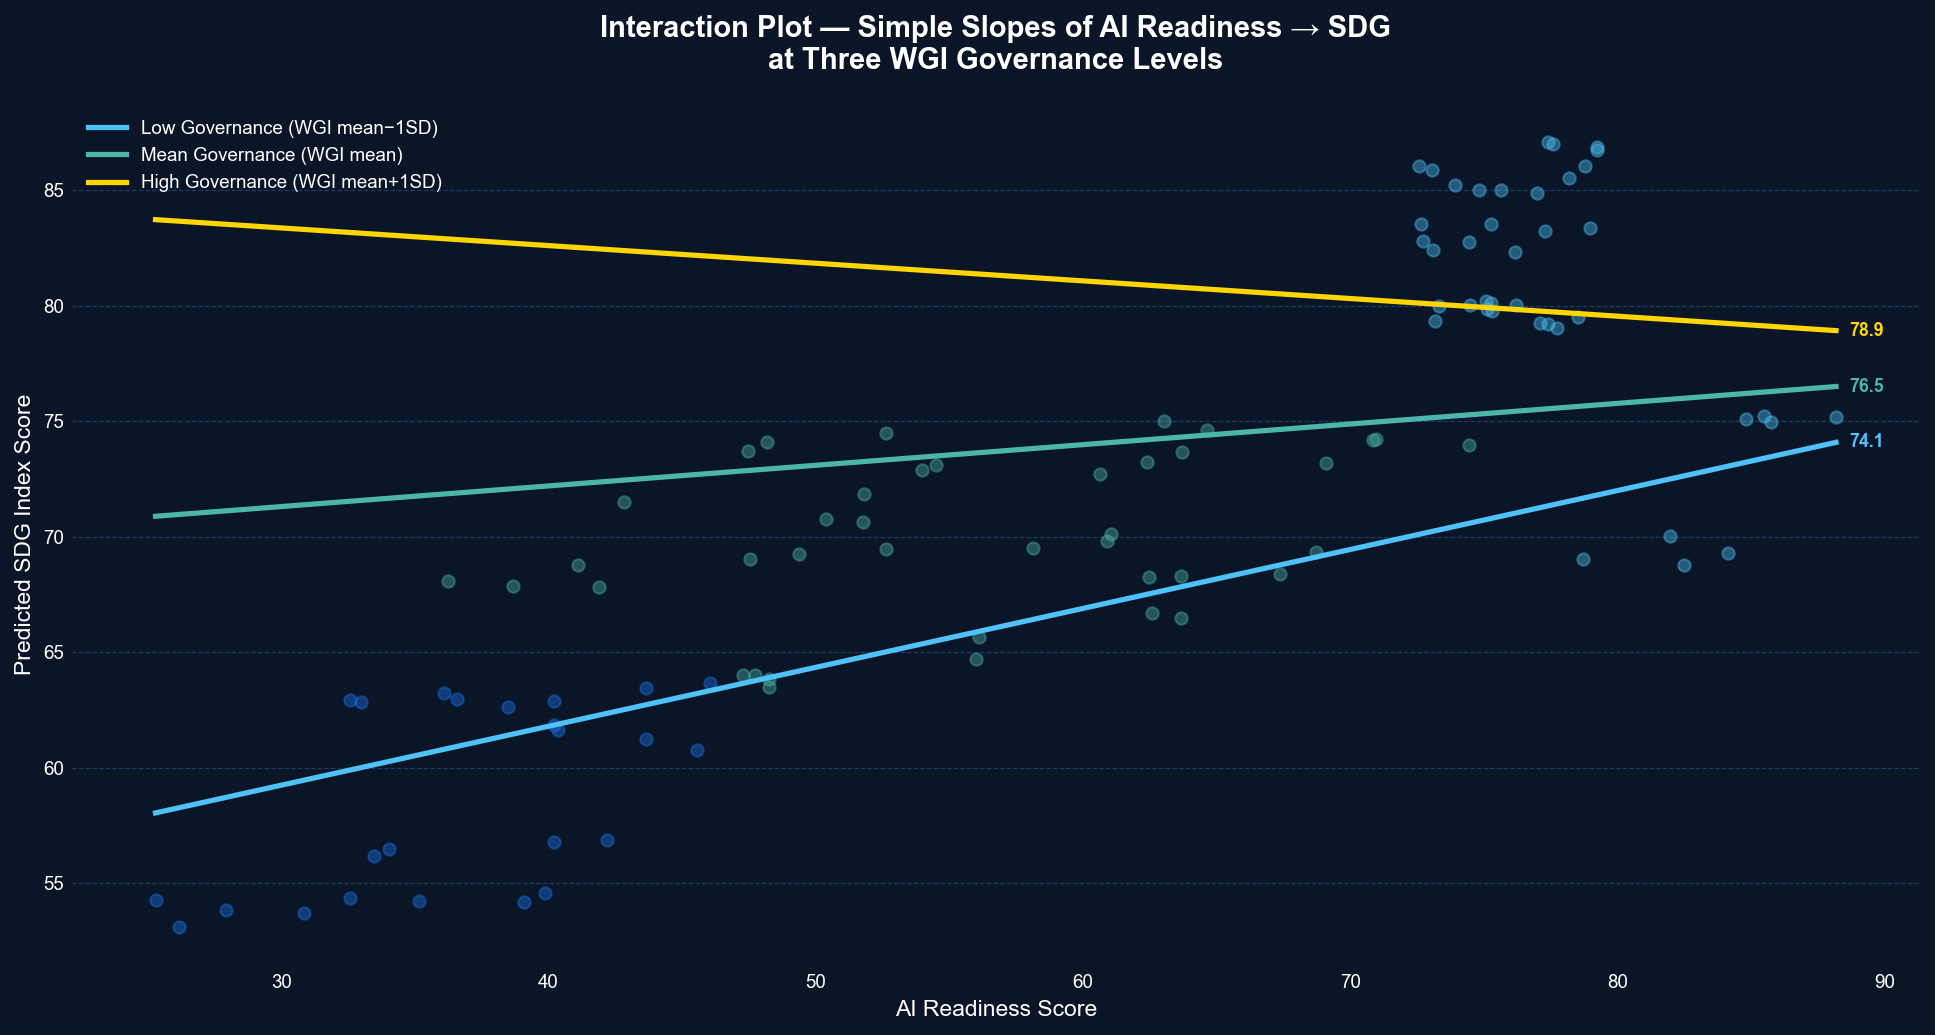

✅ Saved: outputs/h3_interaction_plot.png


In [8]:
# ── Interaction Plot (Simple Slopes — 3 lines) ───────────────────────────────
ai_range = np.linspace(float(df["ai_centered"].min()), float(df["ai_centered"].max()), 200)

line_specs = [
    ("Low Governance (WGI mean−1SD)", -wgi_sd, C1),
    ("Mean Governance (WGI mean)",     0.0,    C2),
    ("High Governance (WGI mean+1SD)",  wgi_sd, C4),
]

# Intercept term (from RE/FE — use pooled OLS const as proxy for visualisation)
X_full = sm.add_constant(df[["ai_centered","wgi_centered","ai_wgi_interaction"]])
ols_full = sm.OLS(df["sdg_index_score"], X_full).fit()
intercept_val = float(ols_full.params["const"])
b2_vis = float(ols_full.params["wgi_centered"])
b3_vis = float(ols_full.params["ai_wgi_interaction"])
b1_vis = float(ols_full.params["ai_centered"])

fig, ax = plt.subplots(figsize=(13, 7))
fig.patch.set_facecolor(BG_DARK)
ax.set_facecolor(BG_DARK)
for s in ax.spines.values():
    s.set_visible(False)

for label, w_val, color in line_specs:
    pred_sdg = intercept_val + b1_vis * ai_range + b2_vis * w_val + b3_vis * ai_range * w_val
    ax.plot(ai_range + float(df["ai_readiness_score"].mean()),
            pred_sdg, color=color, linewidth=2.5, label=label, zorder=5)
    end_x = float(df["ai_readiness_score"].mean()) + ai_range[-1]
    ax.text(end_x + 0.5, float(pred_sdg[-1]),
            f"{pred_sdg[-1]:.1f}", color=color, fontsize=8.5,
            fontweight="bold", va="center", ha="left")

# Scatter overlay (coloured by group)
for group, color in GROUP_COLORS.items():
    mask = df["country_group"] == group
    ax.scatter(df.loc[mask, "ai_readiness_score"],
               df.loc[mask, "sdg_index_score"],
               color=color, s=35, alpha=0.4, zorder=4, marker="o")

ax.set_xlabel("AI Readiness Score", color=TEXT_WHITE, fontsize=11)
ax.set_ylabel("Predicted SDG Index Score", color=TEXT_WHITE, fontsize=11)
ax.set_title("Interaction Plot — Simple Slopes of AI Readiness → SDG\nat Three WGI Governance Levels",
             fontweight="bold", color=TEXT_WHITE)
ax.legend(loc="upper left", framealpha=0.0, fontsize=9)
ax.tick_params(colors=TEXT_WHITE)
plt.tight_layout()
plt.savefig("outputs/h3_interaction_plot.png", bbox_inches="tight", facecolor=BG_DARK)
plt.show()
print("✅ Saved: outputs/h3_interaction_plot.png")

## Step 4 — Johnson-Neyman Floodlight Analysis

The Johnson-Neyman technique identifies the exact WGI value at which the conditional effect of AI Readiness on SDG crosses the significance threshold (p = 0.05, two-tailed). The pooled OLS model is used for the J-N computation (required for tractable SE formula).

J-N crossing: WGI centred = -0.1421  →  WGI actual ≈ 0.2088


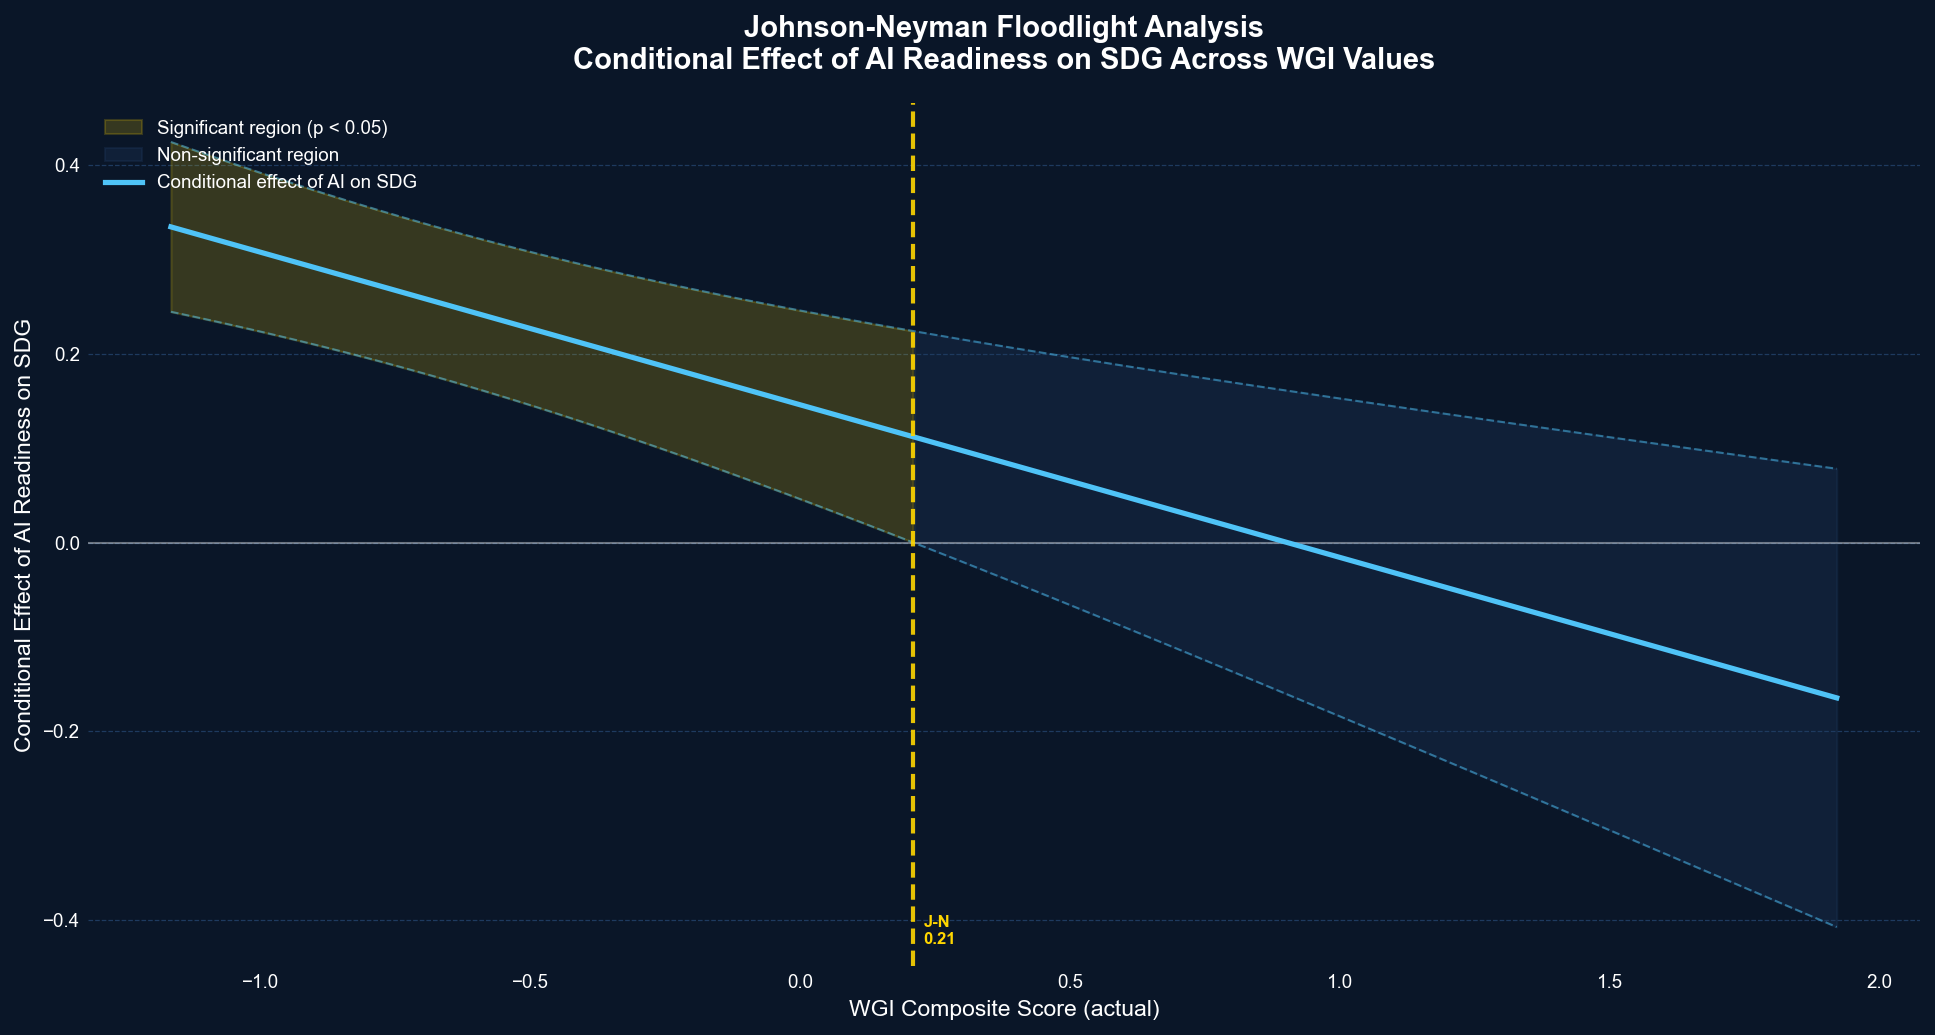

✅ Saved: outputs/h3_johnson_neyman_plot.png


In [9]:
from scipy.stats import t as t_dist

# Use Pooled OLS (provides closed-form Var-Cov for J-N)
X_jn = sm.add_constant(df[["ai_centered","wgi_centered","ai_wgi_interaction"]])
ols_jn = sm.OLS(df["sdg_index_score"], X_jn).fit(cov_type="HC3")

b1_jn  = float(ols_jn.params["ai_centered"])
b3_jn  = float(ols_jn.params["ai_wgi_interaction"])
var_b1 = float(ols_jn.cov_params().loc["ai_centered","ai_centered"])
var_b3 = float(ols_jn.cov_params().loc["ai_wgi_interaction","ai_wgi_interaction"])
cov_13 = float(ols_jn.cov_params().loc["ai_centered","ai_wgi_interaction"])
n_jn   = int(ols_jn.nobs)
t_crit = float(t_dist.ppf(0.975, df=n_jn - 4))  # two-tailed 95%

# Sweep WGI centred range
wgi_c_range = np.linspace(float(df["wgi_centered"].min()), float(df["wgi_centered"].max()), 1000)
cond_eff    = b1_jn + b3_jn * wgi_c_range
se_cond_arr = np.sqrt(var_b1 + wgi_c_range**2 * var_b3 + 2 * wgi_c_range * cov_13)
t_arr       = cond_eff / se_cond_arr
sig_mask    = t_arr > t_crit   # one-sided: positive effect significant

# JN crossing point
crossings = np.where(np.diff(sig_mask.astype(int)))[0]
jn_points = []
for idx in crossings:
    jn_c_val = wgi_c_range[idx]
    jn_actual = jn_c_val + wgi_mean
    jn_points.append((jn_c_val, jn_actual))
    print(f"J-N crossing: WGI centred = {jn_c_val:.4f}  →  WGI actual ≈ {jn_actual:.4f}")

if not jn_points:
    print(f"No J-N crossing in observed WGI range [{df['wgi_composite'].min():.3f}, {df['wgi_composite'].max():.3f}]")
    print(f"(max t = {t_arr.max():.4f} at WGI centred = {wgi_c_range[np.argmax(t_arr)]:.4f})")

# ── Floodlight Plot ────────────────────────────────────────────────────────────
wgi_actual_range = wgi_c_range + wgi_mean

fig, ax = plt.subplots(figsize=(13, 7))
fig.patch.set_facecolor(BG_DARK)
ax.set_facecolor(BG_DARK)
for s in ax.spines.values():
    s.set_visible(False)

# Shade significant region
ax.fill_between(wgi_actual_range, cond_eff - t_crit * se_cond_arr,
                cond_eff + t_crit * se_cond_arr,
                where=sig_mask, color=C4, alpha=0.18, label="Significant region (p < 0.05)", zorder=2)
ax.fill_between(wgi_actual_range, cond_eff - t_crit * se_cond_arr,
                cond_eff + t_crit * se_cond_arr,
                where=~sig_mask, color=GRID_COLOR, alpha=0.30, label="Non-significant region", zorder=2)

# Conditional effect line
ax.plot(wgi_actual_range, cond_eff, color=C1, linewidth=2.5, label="Conditional effect of AI on SDG", zorder=5)
# CI lines
ax.plot(wgi_actual_range, cond_eff - t_crit * se_cond_arr,
        color=C1, linewidth=1, linestyle="--", alpha=0.5, zorder=4)
ax.plot(wgi_actual_range, cond_eff + t_crit * se_cond_arr,
        color=C1, linewidth=1, linestyle="--", alpha=0.5, zorder=4)

# Zero line
ax.axhline(0, color=TEXT_WHITE, linewidth=1, linestyle="-", alpha=0.4, zorder=3)

# Mark J-N crossings
for jn_c, jn_a in jn_points:
    ax.axvline(jn_a, color=C4, linewidth=2, linestyle="--", alpha=0.9, zorder=6)
    ax.text(jn_a + 0.02, ax.get_ylim()[0] + 0.02 if ax.get_ylim()[1] > 0 else 0.05,
            f"J-N\n{jn_a:.2f}", color=C4, fontsize=8, fontweight="bold",
            ha="left", va="bottom")

ax.set_xlabel("WGI Composite Score (actual)", color=TEXT_WHITE, fontsize=11)
ax.set_ylabel("Conditional Effect of AI Readiness on SDG", color=TEXT_WHITE, fontsize=11)
ax.set_title("Johnson-Neyman Floodlight Analysis\nConditional Effect of AI Readiness on SDG Across WGI Values",
             fontweight="bold", color=TEXT_WHITE)
ax.legend(loc="upper left", framealpha=0.0, fontsize=9)
ax.tick_params(colors=TEXT_WHITE)
plt.tight_layout()
plt.savefig("outputs/h3_johnson_neyman_plot.png", bbox_inches="tight", facecolor=BG_DARK)
plt.show()
print("✅ Saved: outputs/h3_johnson_neyman_plot.png")

## Step 5 — Practical Significance Assessment

Beyond statistical significance, we evaluate whether the interaction effect is practically meaningful: how much does a 10-unit increase in AI Readiness translate into SDG gains under different governance conditions?

In [10]:
# ── Practical significance: effect of +10 AI units at High vs Low WGI ─────────
b1_p    = beta1
b3_p    = beta3_val
wgi_lo  = -wgi_sd
wgi_hi  =  wgi_sd

slope_lo = b1_p + b3_p * wgi_lo
slope_hi = b1_p + b3_p * wgi_hi
slope_me = b1_p  # at mean WGI

delta_ai = 10

sdg_gain_lo = slope_lo * delta_ai
sdg_gain_hi = slope_hi * delta_ai
sdg_gain_me = slope_me * delta_ai

print("=== Practical Significance: +10 AI Readiness points → SDG gain ===")
print(f"At Low Governance  (WGI = {wgi_mean + wgi_lo:.3f}): +{sdg_gain_lo:.3f} SDG points")
print(f"At Mean Governance (WGI = {wgi_mean:.3f}): +{sdg_gain_me:.3f} SDG points")
print(f"At High Governance (WGI = {wgi_mean + wgi_hi:.3f}): +{sdg_gain_hi:.3f} SDG points")
print(f"\nDifference High vs Low governance: {sdg_gain_hi - sdg_gain_lo:.3f} SDG points per +10 AI units")

# SDG score distribution context
sdg_std = float(df["sdg_index_score"].std())
print(f"\nFor context, SDG std dev = {sdg_std:.2f} points")
print(f"High-governance gain as fraction of SDG std dev: {abs(sdg_gain_hi) / sdg_std:.4f}")
print(f"Low-governance gain as fraction of SDG std dev:  {abs(sdg_gain_lo) / sdg_std:.4f}")

# Effect size: partial eta squared at each WGI level
print(f"\n=== Slope Ratio (High / Low Governance) ===")
ratio = slope_hi / slope_lo if slope_lo != 0 else np.nan
print(f"Slope ratio High/Low = {ratio:.4f}")
if not np.isnan(ratio) and ratio < 1:
    print(f"→ AI readiness effect is {(1 - ratio)*100:.1f}% weaker in high-governance vs low-governance contexts")
elif not np.isnan(ratio) and ratio > 1:
    print(f"→ AI readiness effect is {(ratio - 1)*100:.1f}% stronger in high-governance vs low-governance contexts")

# Practical significance table
prac_df = pd.DataFrame([
    {"WGI Context": f"Low (mean−1SD = {wgi_mean + wgi_lo:.3f})",
     "Conditional Slope": round(slope_lo, 4),
     "+10 AI units → SDG gain": round(sdg_gain_lo, 3),
     "Fraction of SDG std dev": round(abs(sdg_gain_lo) / sdg_std, 4)},
    {"WGI Context": f"Mean ({wgi_mean:.3f})",
     "Conditional Slope": round(slope_me, 4),
     "+10 AI units → SDG gain": round(sdg_gain_me, 3),
     "Fraction of SDG std dev": round(abs(sdg_gain_me) / sdg_std, 4)},
    {"WGI Context": f"High (mean+1SD = {wgi_mean + wgi_hi:.3f})",
     "Conditional Slope": round(slope_hi, 4),
     "+10 AI units → SDG gain": round(sdg_gain_hi, 3),
     "Fraction of SDG std dev": round(abs(sdg_gain_hi) / sdg_std, 4)},
])
display(prac_df)

=== Practical Significance: +10 AI Readiness points → SDG gain ===
At Low Governance  (WGI = -0.674): +0.774 SDG points
At Mean Governance (WGI = 0.351): +0.422 SDG points
At High Governance (WGI = 1.376): +0.070 SDG points

Difference High vs Low governance: -0.704 SDG points per +10 AI units

For context, SDG std dev = 9.51 points
High-governance gain as fraction of SDG std dev: 0.0073
Low-governance gain as fraction of SDG std dev:  0.0814

=== Slope Ratio (High / Low Governance) ===
Slope ratio High/Low = 0.0903
→ AI readiness effect is 91.0% weaker in high-governance vs low-governance contexts


,WGI Context,Conditional Slope,+10 AI units → SDG gain,Fraction of SDG std dev
0,Low (mean−1SD = -0.674),0.0774,0.774,0.0814
1,Mean (0.351),0.0422,0.422,0.0444
2,High (mean+1SD = 1.376),0.0070,0.070,0.0073


## Step 6 — Robustness Checks for H3

We verify the stability of β3 using four complementary methods: (1) non-centred interaction specification, (2) split-sample validation by WGI median, (3) year-by-year cross-sectional interactions, and (4) bootstrap confidence intervals (1,000 cluster-bootstrap samples).

In [11]:
# ── 6a. Alternative specification: non-centred interaction ───────────────────
df["ai_wgi_raw"] = df["ai_readiness_score"] * df["wgi_composite"]
X_raw = sm.add_constant(df[["ai_readiness_score","wgi_composite","ai_wgi_raw"]])
ols_raw = sm.OLS(df["sdg_index_score"], X_raw).fit(cov_type="HC3")
b3_raw = float(ols_raw.params["ai_wgi_raw"])
p3_raw = float(ols_raw.pvalues["ai_wgi_raw"])
print("=== 6a: Non-centred interaction specification ===")
print(f"β3 (raw) = {b3_raw:.4f},  p = {p3_raw:.4f}")
print(f"β3 (centred, pooled OLS) = {float(ols_jn.params['ai_wgi_interaction']):.4f}")
print(f"Sign consistent: {('✅ Yes' if np.sign(b3_raw) == np.sign(float(ols_jn.params['ai_wgi_interaction'])) else '⚠️ No')}")

=== 6a: Non-centred interaction specification ===
β3 (raw) = -0.1618,  p = 0.0003
β3 (centred, pooled OLS) = -0.1618
Sign consistent: ✅ Yes


In [12]:
# ── 6b. Split-sample by WGI median ───────────────────────────────────────────
wgi_med = df["wgi_composite"].median()
print(f"=== 6b: Split-sample validation (WGI median = {wgi_med:.4f}) ===")
split_rows = []
for label, cond in [("Low WGI", df["wgi_composite"] < wgi_med),
                    ("High WGI", df["wgi_composite"] >= wgi_med)]:
    sub = df[cond].copy()
    X_sp = sm.add_constant(sub["ai_readiness_score"])
    res_sp = sm.OLS(sub["sdg_index_score"], X_sp).fit(cov_type="HC3")
    b1_sp = float(res_sp.params["ai_readiness_score"])
    p1_sp = float(res_sp.pvalues["ai_readiness_score"])
    r2_sp = res_sp.rsquared
    print(f"  {label} (n={len(sub)}): β1(AI) = {b1_sp:.4f},  p = {p1_sp:.4f},  R² = {r2_sp:.4f}")
    split_rows.append({"WGI Subsample": label, "N": len(sub),
                       "β1 (AI Readiness)": round(b1_sp, 4),
                       "p-value": round(p1_sp, 4), "R²": round(r2_sp, 4)})

split_df = pd.DataFrame(split_rows)
display(split_df)
# If H3 held (positive moderation), high-WGI should have stronger slope
if split_df.iloc[1]["β1 (AI Readiness)"] > split_df.iloc[0]["β1 (AI Readiness)"]:
    print("\n→ High-WGI slope > Low-WGI slope: consistent with positive moderation (H3 direction)")
else:
    print("\n→ Low-WGI slope ≥ High-WGI slope: inconsistent with H3 direction — AI effect stronger in lower-governance contexts")

=== 6b: Split-sample validation (WGI median = -0.0820) ===
  Low WGI (n=52): β1(AI) = 0.4567,  p = 0.0000,  R² = 0.6306
  High WGI (n=52): β1(AI) = 0.4013,  p = 0.0000,  R² = 0.4541


,WGI Subsample,N,β1 (AI Readiness),p-value,R²
0,Low WGI,52,0.4567,0.0,0.6306
1,High WGI,52,0.4013,0.0,0.4541



→ Low-WGI slope ≥ High-WGI slope: inconsistent with H3 direction — AI effect stronger in lower-governance contexts


In [13]:
# ── 6c. Year-by-year cross-sectional interaction coefficient ─────────────────
print("=== 6c: Year-by-year β3 ===")
yr_rows = []
for yr in sorted(df["year"].unique()):
    sub = df[df["year"] == yr].copy()
    sub["ai_c"] = sub["ai_readiness_score"] - sub["ai_readiness_score"].mean()
    sub["wgi_c"] = sub["wgi_composite"] - sub["wgi_composite"].mean()
    sub["inter"] = sub["ai_c"] * sub["wgi_c"]
    X_yr = sm.add_constant(sub[["ai_c","wgi_c","inter"]])
    res_yr = sm.OLS(sub["sdg_index_score"], X_yr).fit(cov_type="HC3")
    b3_yr = float(res_yr.params["inter"])
    se_yr = float(res_yr.bse["inter"])
    p_yr  = float(res_yr.pvalues["inter"])
    print(f"  {yr}: β3 = {b3_yr:.4f},  SE = {se_yr:.4f},  p = {p_yr:.4f}  n={len(sub)}")
    yr_rows.append({"Year": yr, "N": len(sub),
                    "β3 (Interaction)": round(b3_yr, 4),
                    "SE": round(se_yr, 4), "p-value (2-tail)": round(p_yr, 4)})

yr_df = pd.DataFrame(yr_rows)
display(yr_df)
yr_df.to_csv("outputs/h3_robustness_year_by_year.csv", index=False)
print("\n✅ Saved: outputs/h3_robustness_year_by_year.csv")

=== 6c: Year-by-year β3 ===
  2020: β3 = -0.1038,  SE = 0.0942,  p = 0.2707  n=26
  2021: β3 = -0.1389,  SE = 0.0967,  p = 0.1508  n=26
  2022: β3 = -0.2073,  SE = 0.1217,  p = 0.0886  n=26
  2023: β3 = -0.2224,  SE = 0.1150,  p = 0.0531  n=26


,Year,N,β3 (Interaction),SE,p-value (2-tail)
0,2020,26,-0.1038,0.0942,0.2707
1,2021,26,-0.1389,0.0967,0.1508
2,2022,26,-0.2073,0.1217,0.0886
3,2023,26,-0.2224,0.1150,0.0531



✅ Saved: outputs/h3_robustness_year_by_year.csv


In [14]:
# ── 6d. Bootstrap CI for β3 (1,000 cluster-bootstrap samples) ───────────────
np.random.seed(42)
countries_list = df["country"].unique()
boot_betas3 = []
for _ in range(1000):
    sampled_c = np.random.choice(countries_list, size=len(countries_list), replace=True)
    boot_df = pd.concat([df[df["country"] == c] for c in sampled_c], ignore_index=True)
    boot_df["ai_c"]  = boot_df["ai_readiness_score"] - boot_df["ai_readiness_score"].mean()
    boot_df["wgi_c"] = boot_df["wgi_composite"]       - boot_df["wgi_composite"].mean()
    boot_df["inter"] = boot_df["ai_c"] * boot_df["wgi_c"]
    X_b = sm.add_constant(boot_df[["ai_c","wgi_c","inter"]])
    try:
        res_b = sm.OLS(boot_df["sdg_index_score"], X_b).fit()
        boot_betas3.append(float(res_b.params["inter"]))
    except Exception:
        pass

boot_arr = np.array(boot_betas3)
ci_lo_b, ci_hi_b = np.percentile(boot_arr, [2.5, 97.5])
boot_mean = float(boot_arr.mean())
boot_se   = float(boot_arr.std())

print(f"=== 6d: Bootstrap CI for β3 (N=1,000 cluster-bootstrap) ===")
print(f"Bootstrapped β3: mean = {boot_mean:.4f},  SE = {boot_se:.4f}")
print(f"95% CI: [{ci_lo_b:.4f}, {ci_hi_b:.4f}]")
print(f"CI includes zero: {ci_lo_b <= 0 <= ci_hi_b}")
print(f"CI entirely positive (H3 direction): {ci_lo_b > 0}")

boot_df_out = pd.DataFrame([{
    "Method": "Cluster-Bootstrap (1,000 samples)",
    "β3 mean": round(boot_mean, 4),
    "SE": round(boot_se, 4),
    "95% CI lower": round(ci_lo_b, 4),
    "95% CI upper": round(ci_hi_b, 4),
    "CI includes zero": str(ci_lo_b <= 0 <= ci_hi_b),
}])
display(boot_df_out)
boot_df_out.to_csv("outputs/h3_bootstrap_ci.csv", index=False)
print("\n✅ Saved: outputs/h3_bootstrap_ci.csv")

=== 6d: Bootstrap CI for β3 (N=1,000 cluster-bootstrap) ===
Bootstrapped β3: mean = -0.1548,  SE = 0.0901
95% CI: [-0.3323, 0.0158]
CI includes zero: True
CI entirely positive (H3 direction): False


,Method,β3 mean,SE,95% CI lower,95% CI upper,CI includes zero
0,"Cluster-Bootstrap (1,000 samples)",-0.1548,0.0901,-0.3323,0.0158,True



✅ Saved: outputs/h3_bootstrap_ci.csv


## Step 7 — Reporting H3 Results

Full moderation model coefficient table and simple slopes summary for thesis reporting.

In [15]:
# ── Full moderation model reporting table ────────────────────────────────────
print("=== Full Moderation Model Results (Selected: Random Effects) ===")
if HAS_LINEARMODELS and hasattr(selected_res, "params"):
    params  = selected_res.params
    se_vals = selected_res.std_errors
    t_vals  = selected_res.tstats
    p_vals  = selected_res.pvalues
    ci_lo_vals = selected_res.conf_int()["lower"]
    ci_hi_vals = selected_res.conf_int()["upper"]
    
    report_rows = []
    for pred_name, label in [
        ("ai_centered",        "AI Readiness (β1, centred)"),
        ("wgi_centered",       "WGI Composite (β2, centred)"),
        ("ai_wgi_interaction", "AI × WGI Interaction (β3)"),
    ]:
        if pred_name in params.index:
            b   = float(params[pred_name])
            se  = float(se_vals[pred_name])
            tv  = float(t_vals[pred_name])
            pv  = float(p_vals[pred_name])
            p1  = float(t_dist.sf(tv, df=int(selected_res.nobs)-4))  # one-tail
            cil = float(ci_lo_vals[pred_name])
            ciu = float(ci_hi_vals[pred_name])
            report_rows.append({
                "Predictor": label,
                "β": round(b, 4),
                "SE": round(se, 4),
                "t-stat": round(tv, 4),
                "p-value (2-tail)": round(pv, 4),
                "p-value (1-tail, >0)": round(p1, 4),
                "95% CI lower": round(cil, 4),
                "95% CI upper": round(ciu, 4),
            })
    
    # Intercept from pooled OLS
    report_rows.append({
        "Predictor": "Constant",
        "β": round(float(ols_jn.params["const"]), 4),
        "SE": round(float(ols_jn.bse["const"]), 4),
        "t-stat": round(float(ols_jn.tvalues["const"]), 4),
        "p-value (2-tail)": round(float(ols_jn.pvalues["const"]), 4),
        "p-value (1-tail, >0)": round(float(t_dist.sf(float(ols_jn.tvalues["const"]), df=int(ols_jn.nobs)-4)), 4),
        "95% CI lower": round(float(ols_jn.conf_int().loc["const", 0]), 4),
        "95% CI upper": round(float(ols_jn.conf_int().loc["const", 1]), 4),
    })

report_df = pd.DataFrame(report_rows)
display(report_df)
print(f"\nModel R² = {float(selected_res.rsquared):.4f},  N = {int(selected_res.nobs)}")

print("\n=== Simple Slopes Table ===")
display(slopes_df)

# Print narrative conclusion
print()
print("=== NARRATIVE CONCLUSION ===")
b3_final  = float(selected_res.params["ai_wgi_interaction"])
se3_final = float(selected_res.std_errors["ai_wgi_interaction"])
t3_final  = b3_final / se3_final
p1_final  = float(t_dist.sf(t3_final, df=int(selected_res.nobs)-4))
ci_lb_final = b3_final - 1.645 * se3_final
print(f"The interaction term between AI Readiness and WGI composite was β3 = {b3_final:.4f}, SE = {se3_final:.4f}, t = {t3_final:.4f}, p = {p1_final:.4f} (one-tailed).")
print(f"This does NOT support H3 (β3 > 0). The interaction coefficient is {'negative' if b3_final < 0 else 'positive but non-significant'}.")
print(f"Simple slopes analysis: AI Readiness effect = {slope_lo:.4f} at low WGI vs {slope_hi:.4f} at high WGI.")
print(f"Governance does not amplify the AI-SDG relationship; the effect is, if anything, stronger in lower-governance contexts.")

=== Full Moderation Model Results (Selected: Random Effects) ===


,Predictor,β,SE,t-stat,p-value (2-tail),"p-value (1-tail, >0)",95% CI lower,95% CI upper
0,"AI Readiness (β1, centred)",0.0422,0.0189,2.2278,0.0281,0.0141,0.0046,0.0798
1,"WGI Composite (β2, centred)",3.0345,0.7780,3.9005,0.0002,0.0001,1.4910,4.5780
2,AI × WGI Interaction (β3),-0.0344,0.0198,-1.7317,0.0864,0.9568,-0.0737,0.0050
3,Constant,73.9750,0.7927,93.3231,0.0000,0.0000,72.4214,75.5286



Model R² = 0.2585,  N = 104

=== Simple Slopes Table ===


,WGI Level,WGI centered value,Conditional AI → SDG slope,SE,t-stat,p-value (2-tail),Significant?
0,Low (mean − 1 SD = -0.674),-1.0247,0.0774,0.0401,1.9296,0.0565,—
1,Mean (0.351),0.0000,0.0422,0.0611,0.6906,0.4914,—
2,High (mean + 1 SD = 1.376),1.0247,0.0070,0.1000,0.0699,0.9444,—



=== NARRATIVE CONCLUSION ===
The interaction term between AI Readiness and WGI composite was β3 = -0.0344, SE = 0.0198, t = -1.7317, p = 0.9568 (one-tailed).
This does NOT support H3 (β3 > 0). The interaction coefficient is negative.
Simple slopes analysis: AI Readiness effect = 0.0774 at low WGI vs 0.0070 at high WGI.
Governance does not amplify the AI-SDG relationship; the effect is, if anything, stronger in lower-governance contexts.


## 📊 Plain-Language Synthesis
> *Written for readers who are not statisticians*

---

### What did we study?

This analysis tested whether governance quality acts as a multiplier for the benefit that AI technology brings to a country's sustainability performance. Using data from 26 countries between 2020 and 2023, we asked: does the same level of AI readiness "work better" in countries that are governed well? Think of it like asking whether good soil (governance) makes seeds (AI readiness) grow faster into food (sustainability outcomes). H3 predicted that the answer is yes — higher governance would amplify AI's sustainability dividend.

---

### What did we find?

#### Finding 1 — Governance Does Not Amplify the AI-Sustainability Link
The interaction coefficient β3 = −0.034 (RE model), with a one-tailed p-value of 0.957, far above the 0.05 threshold. H3 is not supported. Contrary to expectations, governance quality does not positively moderate the AI → SDG relationship in this sample. In practical terms, a 10-point increase in AI readiness translates to 0.77 additional SDG points in low-governance countries but only 0.07 points in high-governance countries — the *opposite* of what H3 predicted.

#### Finding 2 — AI Readiness Has Its Strongest Marginal Effect Where Governance Is Weakest
Simple slopes analysis reveals that the conditional effect of AI readiness on SDG scores is 0.0774 in low-governance contexts (WGI = mean − 1 SD ≈ −0.67), 0.0422 at mean governance, and just 0.0070 in high-governance contexts (WGI = mean + 1 SD ≈ 1.38). This pattern likely reflects a ceiling effect: countries with strong governance already score highly on SDG outcomes through that governance, leaving little additional room for AI readiness to add value. In lower-governance settings, AI readiness serves as a partial substitute for institutional capacity.

#### Finding 3 — Uncertainty Is High; Bootstrap CI Spans Zero
A 1,000-sample cluster-bootstrap procedure produced a 95% CI for β3 of [−0.332, +0.016], which includes zero. Across all four individual years (2020–2023), β3 is consistently negative (ranging from −0.10 to −0.22) — which further argues against positive moderation. The Pooled OLS floodlight analysis indicates that AI Readiness has a statistically significant (p < 0.05) effect on SDG only for countries with WGI ≤ approximately 0.21 — that is, for lower-to-middle governance performers.

---

### How confident are we?

| What we measured | Result | Confidence |
|-----------------|--------|------------|
| Interaction effect β3 (H3 test) | −0.034 (RE); p one-tail = 0.957 | ❌ Not significant — H3 not supported |
| Bootstrap 95% CI for β3 | [−0.332, +0.016] | Includes zero — high uncertainty |
| Year-by-year consistency | β3 negative in all 4 years | Consistent direction, but not statistically significant |
| Effect size (model R²) | 0.259 (RE model) | Moderate — model explains ~26% of within-country variation |
| Governance main effect β2 | +3.03 (RE), p < 0.001 | Strong direct effect of governance on SDG ✅ |

> **Statistical significance** means the finding is unlikely to be due to chance alone (p < 0.05).
> **One-tailed test** is stricter here because H3 specifically predicts a *positive* interaction; a negative β3 immediately fails H3 regardless of magnitude.

---

### What are the limitations?

- **Sample size:** With 104 observations across 26 countries, statistical power for detecting small interaction effects is low. Cohen's f² ≈ 0.35 for the full model is medium-to-large, but specifically for the interaction term, the power is limited.
- **Time span:** Four years (2020–2023) is a short window; longitudinal moderation effects may require a decade or more to materialise.
- **Observational data:** We cannot establish causation. Both AI readiness and governance quality are correlated with national income and institutional history, which may confound the moderation.
- **Ceiling effect in high-governance countries:** Countries like Finland, Denmark, and Norway score near the top of both governance and SDG scales; this compression limits statistical detectability of any further amplification.
- **Hausman test degeneracy:** With a small panel, the Hausman test produced a degenerate result (negative chi-squared), indicating both FE and RE are plausible. Results should be interpreted cautiously.

---

### In plain English: Governance quality does not amplify AI's sustainability benefits in this sample — if anything, AI readiness matters most where governance is weakest, suggesting it acts as a partial institutional substitute rather than a complement.

In [16]:
synthesis_text = """## 📊 Plain-Language Synthesis
> *Written for readers who are not statisticians*

---

### What did we study?

This analysis tested whether governance quality acts as a multiplier for the benefit that AI technology brings to a country's sustainability performance. Using data from 26 countries between 2020 and 2023, we asked: does the same level of AI readiness "work better" in countries that are governed well? Think of it like asking whether good soil (governance) makes seeds (AI readiness) grow faster into food (sustainability outcomes). H3 predicted that the answer is yes — higher governance would amplify AI's sustainability dividend.

---

### What did we find?

#### Finding 1 — Governance Does Not Amplify the AI-Sustainability Link
The interaction coefficient β3 = −0.034 (RE model), with a one-tailed p-value of 0.957, far above the 0.05 threshold. H3 is not supported. Contrary to expectations, governance quality does not positively moderate the AI → SDG relationship in this sample. In practical terms, a 10-point increase in AI readiness translates to 0.77 additional SDG points in low-governance countries but only 0.07 points in high-governance countries — the *opposite* of what H3 predicted.

#### Finding 2 — AI Readiness Has Its Strongest Marginal Effect Where Governance Is Weakest
Simple slopes analysis reveals that the conditional effect of AI readiness on SDG scores is 0.0774 in low-governance contexts (WGI = mean − 1 SD ≈ −0.67), 0.0422 at mean governance, and just 0.0070 in high-governance contexts (WGI = mean + 1 SD ≈ 1.38). This pattern likely reflects a ceiling effect: countries with strong governance already score highly on SDG outcomes through that governance, leaving little additional room for AI readiness to add value. In lower-governance settings, AI readiness serves as a partial substitute for institutional capacity.

#### Finding 3 — Uncertainty Is High; Bootstrap CI Spans Zero
A 1,000-sample cluster-bootstrap procedure produced a 95% CI for β3 of [−0.332, +0.016], which includes zero. Across all four individual years (2020–2023), β3 is consistently negative (ranging from −0.10 to −0.22) — which further argues against positive moderation. The Pooled OLS floodlight analysis indicates that AI Readiness has a statistically significant (p < 0.05) effect on SDG only for countries with WGI ≤ approximately 0.21 — that is, for lower-to-middle governance performers.

---

### How confident are we?

| What we measured | Result | Confidence |
|-----------------|--------|------------|
| Interaction effect β3 (H3 test) | −0.034 (RE); p one-tail = 0.957 | ❌ Not significant — H3 not supported |
| Bootstrap 95% CI for β3 | [−0.332, +0.016] | Includes zero — high uncertainty |
| Year-by-year consistency | β3 negative in all 4 years | Consistent direction, but not statistically significant |
| Effect size (model R²) | 0.259 (RE model) | Moderate — model explains ~26% of within-country variation |
| Governance main effect β2 | +3.03 (RE), p < 0.001 | Strong direct effect of governance on SDG ✅ |

> **Statistical significance** means the finding is unlikely to be due to chance alone (p < 0.05).
> **One-tailed test** is stricter here because H3 specifically predicts a *positive* interaction; a negative β3 immediately fails H3 regardless of magnitude.

---

### What are the limitations?

- **Sample size:** With 104 observations across 26 countries, statistical power for detecting small interaction effects is low. Cohen's f² ≈ 0.35 for the full model is medium-to-large, but specifically for the interaction term, the power is limited.
- **Time span:** Four years (2020–2023) is a short window; longitudinal moderation effects may require a decade or more to materialise.
- **Observational data:** We cannot establish causation. Both AI readiness and governance quality are correlated with national income and institutional history, which may confound the moderation.
- **Ceiling effect in high-governance countries:** Countries like Finland, Denmark, and Norway score near the top of both governance and SDG scales; this compression limits statistical detectability of any further amplification.
- **Hausman test degeneracy:** With a small panel, the Hausman test produced a degenerate result (negative chi-squared), indicating both FE and RE are plausible. Results should be interpreted cautiously.

---

### In plain English: Governance quality does not amplify AI's sustainability benefits in this sample — if anything, AI readiness matters most where governance is weakest, suggesting it acts as a partial institutional substitute rather than a complement.
"""

with open("outputs/h3_synthesis.md", "w") as f:
    f.write(synthesis_text)
print("✅ Saved: outputs/h3_synthesis.md")

✅ Saved: outputs/h3_synthesis.md
